In [10]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'left')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['target_column', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['target_column', 'target_instances', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [12]:
# Define custom matplotlib colors by their index
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\1542399238.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


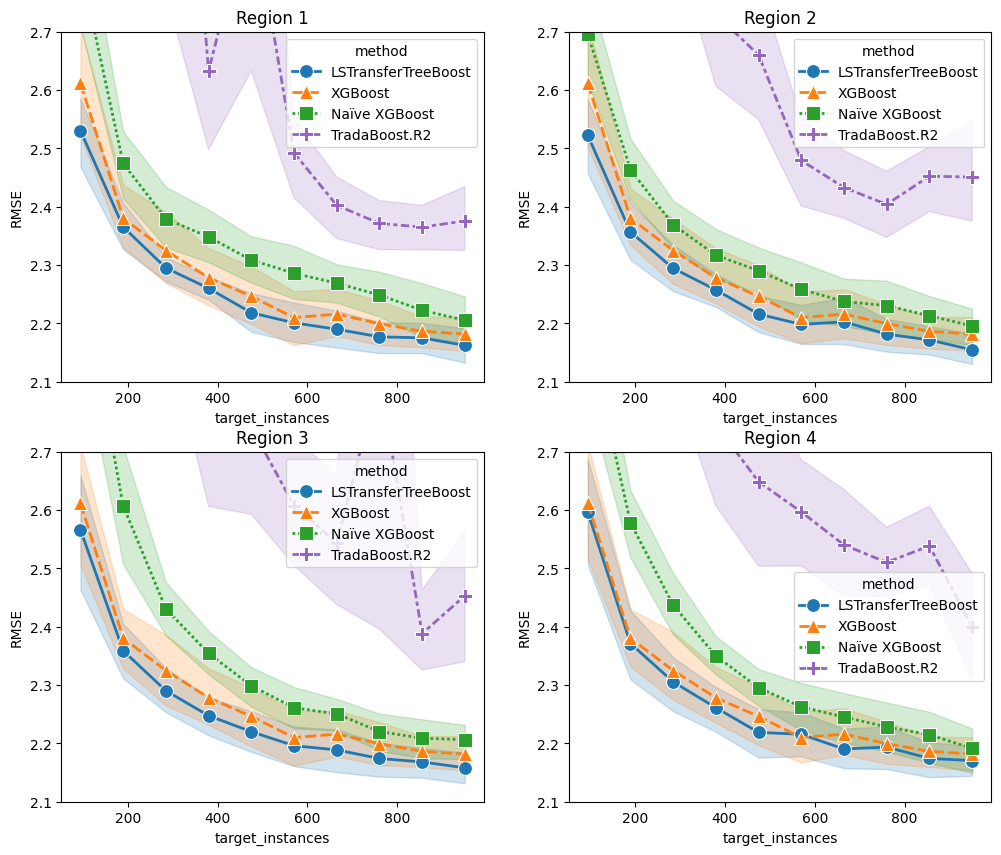

In [13]:
from matplotlib.lines import Line2D
plt.figure(figsize = (12,10))
for d in [1,2,3,4]:

    target_column  = 'Hgv'
   
    dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_DGV_rs_{d}_250926.csv', index_col = [0])
    dat = dat.reset_index(drop=True) 
    dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])
    
    best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
        dat,
    ['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
    )
    



    data = pd.read_csv(f'results/xgboost_ablation_DGV_rs_{d}_250926.csv')
    xgboost_data = data[data['method'] == 'xgboost']
    naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
    naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
    naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
    xgboost_data['method'] = 'XGBoost'

    best_XGBoost, _ = topk_per_d_per_method(
        xgboost_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )

    """
    best_naive_transfer, _ = topk_per_d_per_method(
        naive_transfer_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
    )

    """
    best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
        naive_transfer_data_with_dummy,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )
    



    best_mlp, _ = topk_per_d_per_method(
        f'../results/MLP_ablation_rs.csv',
    ['target_column', 'target_instances', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
    )



    trada = pd.read_csv(f'../results/tradaboost_ablation_rs_{d}_251001_mixed.csv')
    print(len(trada))
    trada = trada.drop(trada.index[360]).reset_index(drop=True)
    print(len(trada))
    trada['method'] = 'TradaBoost.R2'
    numeric_cols = ["Unnamed: 0", "seed", "target_instances", "n_estimators", 
                "lr", "tree_size", "val_rmse", "val_mae", "rmse", "mae"]

    for col in numeric_cols:
        trada[col] = pd.to_numeric(trada[col], errors="coerce")
    best_tradaboost, kk = topk_per_d_per_method(
        trada,
    ['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=10
    )
    
    #trada = trada.rename(columns = {'train_size_': 'target_instances'})
    best_tradaboost, kk = topk_per_d_per_method(
        trada,
    ['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=10
    )


    #df = best_XGBoost
    df = best_LSTransferTreeBoost
    df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
    #df = pd.concat([df, best_naive_transfer])
    df = pd.concat([df, best_naive_transfer_with_dummy])
    #df = pd.concat([df, best_mlp])
    df = pd.concat([df, best_tradaboost])
    plt.subplot(2,2,d)
    marker_dict = {
    'LSTransferTreeBoost': 'o',
    'XGBoost': '^',
    'Naïve XGBoost': 's',
    'Finetuned MLP': 'D',
    'TradaBoost.R2': 'P'
}

    linestyles_dict = {
        'LSTransferTreeBoost': '-',
        'XGBoost': '--', 
        'Naïve XGBoost': '-.', 
        'Finetuned MLP': ':', 
        'TradaBoost.R2': (0, (3, 1, 1, 1)),
    }
        
    linestyles_dict=['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

    
    sns.lineplot(
    data=df,
    x='target_instances', y='rmse', hue='method',
    style='method',                # needed to activate markers/dashes mapping
    markers=marker_dict,            # adds shaded confidence intervals
    linewidth=2,
    markersize=10,
    errorbar='ci')
    plt.ylabel('RMSE')
    plt.ylim([2.1, 2.7])
    plt.title(f'Region {d}')  
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)

plt.savefig('vizes/HGV_DGV_all.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 300)



In [14]:
kk

,target_column,target_instances,n_estimators,lr,tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,method,val_rmse,val_mae,rmse,mae
1103,Hgv,950,10,0.5,1,2.453410,1.800179,10,0.0,6,TradaBoost.R2,2.497829,1.893490,2.347568,1.744510
1102,Hgv,950,10,0.5,1,2.453410,1.800179,10,0.0,3,TradaBoost.R2,2.768218,1.946387,2.786229,1.784074
1109,Hgv,950,10,0.5,1,2.453410,1.800179,10,0.0,10,TradaBoost.R2,2.643879,1.805914,2.409930,1.679439
1108,Hgv,950,10,0.5,1,2.453410,1.800179,10,0.0,8,TradaBoost.R2,2.315382,1.750130,2.327903,1.751173
1107,Hgv,950,10,0.5,1,2.453410,1.800179,10,0.0,9,TradaBoost.R2,2.448630,1.769765,2.274278,1.692569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,Hgv,95,20,0.1,1,5.463308,3.456889,10,0.0,9,TradaBoost.R2,5.594586,3.534851,4.858535,3.514698
43,Hgv,95,20,0.1,1,5.463308,3.456889,10,0.0,6,TradaBoost.R2,7.666692,3.932490,10.369604,4.117983
42,Hgv,95,20,0.1,1,5.463308,3.456889,10,0.0,3,TradaBoost.R2,4.962205,3.432373,4.220286,3.135401
41,Hgv,95,20,0.1,1,5.463308,3.456889,10,0.0,1,TradaBoost.R2,4.392902,3.251495,5.222399,3.373490


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2980773936.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


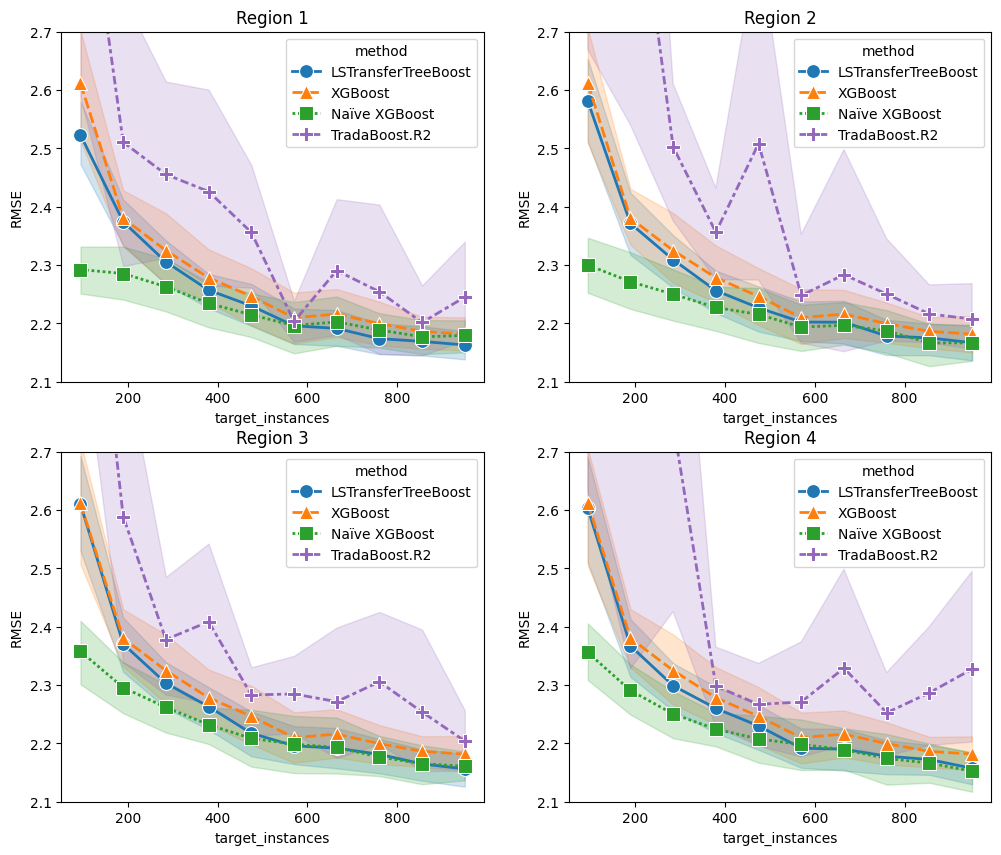

In [15]:
from matplotlib.lines import Line2D
plt.figure(figsize = (12,10))
for d in [1,2,3,4]:

    target_column  = 'Hgv'
   
    dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_rs_{d}_250927.csv', index_col = [0])
    dat = dat.reset_index(drop=True) 
    dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])
    #dat = dat[dat['seed'].isin([1, 2, 3])]
  
    best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
        dat,
    ['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
    )
    



    data = pd.read_csv(f'results/xgboost_ablation_HGV_rs_{d}_250926.csv')
    xgboost_data = data[data['method'] == 'xgboost']
    naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
    naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
    naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
    xgboost_data['method'] = 'XGBoost'

    best_XGBoost, _ = topk_per_d_per_method(
        xgboost_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )

    """
    best_naive_transfer, _ = topk_per_d_per_method(
        naive_transfer_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
    )

    """
    best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
        naive_transfer_data_with_dummy,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )
    



    best_mlp, _ = topk_per_d_per_method(
        f'../results/MLP_ablation_rs.csv',
    ['target_column', 'target_instances', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
    )



    trada = pd.read_csv(f'../results/tradaboost_ablation_rs_{d}_251001.csv')
    print(len(trada))
    trada = trada.drop(trada.index[360]).reset_index(drop=True)
    print(len(trada))
    trada['method'] = 'TradaBoost.R2'
    numeric_cols = ["Unnamed: 0", "seed", "target_instances", "n_estimators", 
                "lr", "tree_size", "val_rmse", "val_mae", "rmse", "mae"]

    for col in numeric_cols:
        trada[col] = pd.to_numeric(trada[col], errors="coerce")
    best_tradaboost, kk = topk_per_d_per_method(
        trada,
    ['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=10
    )


    #df = best_XGBoost
    df = best_LSTransferTreeBoost
    df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
    #df = pd.concat([df, best_naive_transfer])
    df = pd.concat([df, best_naive_transfer_with_dummy])
    #df = pd.concat([df, best_mlp])
    df = pd.concat([df, best_tradaboost])
    plt.subplot(2,2,d)

    marker_dict = {
    'LSTransferTreeBoost': 'o',
    'XGBoost': '^',
    'Naïve XGBoost': 's',
    'Finetuned MLP': 'D',
    'TradaBoost.R2': 'P'
}

    linestyles_dict = {
        'LSTransferTreeBoost': '-',
        'XGBoost': '--', 
        'Naïve XGBoost': '-.', 
        'Finetuned MLP': ':', 
        'TradaBoost.R2': (0, (3, 1, 1, 1)),
    }
        
    linestyles_dict=['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

    
    sns.lineplot(
    data=df,
    x='target_instances', y='rmse', hue='method',
    style='method',                # needed to activate markers/dashes mapping
    markers=marker_dict,            # adds shaded confidence intervals
    linewidth=2,
    markersize=10,
    errorbar='ci')

    plt.ylabel('RMSE')
    plt.ylim([2.1, 2.7])
    plt.title(f'Region {d}')   
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)

plt.savefig('vizes/HGV_HGV_all.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 300)




C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\3207361441.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\3207361441.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
1200


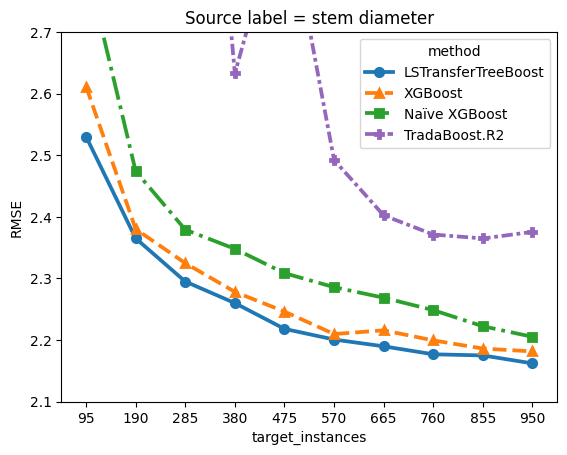

In [16]:
from matplotlib.lines import Line2D


target_column  = 'Hgv'

dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_DGV_rs_1_250926.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
)




data = pd.read_csv(f'results/xgboost_ablation_DGV_rs_1_250926.csv')
xgboost_data = data[data['method'] == 'xgboost']
naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
xgboost_data['method'] = 'XGBoost'

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
)

"""
best_naive_transfer, _ = topk_per_d_per_method(
    naive_transfer_data,
['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
)

"""
best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
    naive_transfer_data_with_dummy,
['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
)




best_mlp, _ = topk_per_d_per_method(
    f'../results/MLP_ablation_rs.csv',
['target_column', 'target_instances', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
)



trada = pd.read_csv(f'../results/tradaboost_ablation_rs_1_251001_mixed.csv')
print(len(trada))
trada = trada.drop(trada.index[360]).reset_index(drop=True)
print(len(trada))
trada['method'] = 'TradaBoost.R2'
numeric_cols = ["Unnamed: 0", "seed", "target_instances", "n_estimators", 
            "lr", "tree_size", "val_rmse", "val_mae", "rmse", "mae"]

for col in numeric_cols:
    trada[col] = pd.to_numeric(trada[col], errors="coerce")
best_tradaboost, kk = topk_per_d_per_method(
    trada,
['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=10
)



#df = best_XGBoost
df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_naive_transfer])
df = pd.concat([df, best_naive_transfer_with_dummy])
#df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])
sns.pointplot(data = df[df['target_column'] == target_column], x = 'target_instances', y = 'rmse', hue = 'method',  errorbar=None, 
                markers=['o', '^', 's', 'P'], markersize=6, linestyles=['-', '--', '-.', (0, (3, 1, 1, 1))])
plt.ylabel('RMSE')
plt.ylim([2.1, 2.7]) 
plt.title('Source label = stem diameter') 
# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)

plt.savefig('vizes/HGV_DGV_1.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 300)



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2558761625.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_11252\2558761625.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'


1201
Index(['Unnamed: 0', 'seed', 'target_column', 'target_instances', 'method',
       'n_estimators', 'lr', 'tree_size', 'val_rmse', 'val_mae', 'rmse',
       'mae'],
      dtype='object')


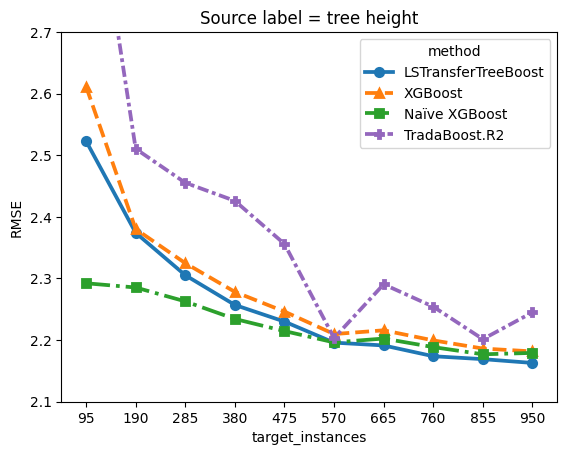

In [17]:
from matplotlib.lines import Line2D


target_column  = 'Hgv'

dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_rs_1_250927.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
)




data = pd.read_csv(f'results/xgboost_ablation_HGV_rs_1_250926.csv')
xgboost_data = data[data['method'] == 'xgboost']
naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
xgboost_data['method'] = 'XGBoost'

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
)

"""
best_naive_transfer, _ = topk_per_d_per_method(
    naive_transfer_data,
['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
)

"""
best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
    naive_transfer_data_with_dummy,
['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
)








trada = pd.read_csv(f'../results/tradaboost_ablation_rs_1_251001.csv')
print(len(trada))
trada = trada.drop(trada.index[360]).reset_index(drop=True)
print(trada.columns)
trada['method'] = 'TradaBoost.R2'
numeric_cols = ["Unnamed: 0", "seed", "target_instances", "n_estimators", 
            "lr", "tree_size", "val_rmse", "val_mae", "rmse", "mae"]

for col in numeric_cols:
    trada[col] = pd.to_numeric(trada[col], errors="coerce")
best_tradaboost, kk = topk_per_d_per_method(
    trada,
['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=10
)


#df = best_XGBoost
df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_naive_transfer])
df = pd.concat([df, best_naive_transfer_with_dummy])
#df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])
sns.pointplot(data = df[df['target_column'] == target_column], x = 'target_instances', y = 'rmse', hue = 'method',  errorbar=None, 
                markers=['o', '^', 's', 'P'], markersize=6, linestyles=['-', '--', '-.', (0, (3, 1, 1, 1))])
plt.ylabel('RMSE')
plt.ylim([2.1, 2.7]) 
plt.title('Source label = tree height') 
# grab the current legend
handles, labels = plt.gca().get_legend_handles_labels()

# rebuild legend with longer lines
new_handles = []
for h in handles:
    if isinstance(h, Line2D):
        new_handles.append(Line2D(
            [0], [0], 
            color=h.get_color(),
            linestyle=h.get_linestyle(),
            marker=h.get_marker(),
            markersize=6,
            linewidth=2,
        ))
    else:
        new_handles.append(h)

plt.savefig('vizes/HGV_HGV_1.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 300)




In [18]:
trada[350:370]

,Unnamed: 0,seed,target_column,target_instances,method,n_estimators,lr,tree_size,val_rmse,val_mae,rmse,mae
350,0.0,3,Hgv,950,TradaBoost.R2,20,0.5,2,2.970232,1.987121,2.839355,1.985846
351,0.0,3,Hgv,665,TradaBoost.R2,30,0.5,2,3.405551,2.160346,2.968119,2.002026
352,0.0,3,Hgv,855,TradaBoost.R2,30,0.1,2,2.648928,1.777866,2.365499,1.662287
353,0.0,3,Hgv,950,TradaBoost.R2,30,0.1,1,2.631149,1.864970,2.378391,1.679969
354,0.0,3,Hgv,760,TradaBoost.R2,30,0.5,2,3.405176,2.132714,3.382069,2.084701
355,0.0,3,Hgv,855,TradaBoost.R2,30,0.5,1,2.925143,2.088404,2.615229,1.921991
356,0.0,3,Hgv,950,TradaBoost.R2,30,0.1,2,2.619547,1.777134,2.321078,1.668923
357,0.0,3,Hgv,855,TradaBoost.R2,30,0.5,2,2.928433,1.926837,2.957133,1.940359
358,0.0,3,Hgv,950,TradaBoost.R2,30,0.5,1,2.874368,2.057130,2.624842,1.962206
359,0.0,3,Hgv,950,TradaBoost.R2,30,0.5,2,2.801110,1.820160,2.640602,1.903213
